In [3]:
%pip install scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sentence_transformers import SentenceTransformer

C:\Users\Lenovo yoga\PycharmProjects\darazscraper\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = SentenceTransformer("all-MiniLM-L6-v2")
sentence = "My name is Yar Khan."
sentence_embeddings = model.encode(sentence)
print(f"the sentence is: {sentence}\n")
print(f"Dimensions of embeddings are:{len(sentence_embeddings)}")
print(f"First 10 vectors are: {sentence_embeddings[:10]}\n")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2757.81it/s]


the sentence is: My name is Yar Khan.

Dimensions of embeddings are:384
First 10 vectors are: [-0.10117589  0.06108612  0.04034893  0.01089908 -0.07207182 -0.11687545
  0.11590641 -0.01881589  0.05967554 -0.07325028]



In [6]:
multiple_sentences = ["His name is wadood",
                      "He love cats and dogs",
                      "He also like the kittens",
                      "He also have form of hens"]

embeds = model.encode(multiple_sentences)

print(f"The shape of the embeddings are :{embeds.shape}\n")
#number of sentences, each with its dimensions
print(f"  → {embeds.shape[0]} sentences, each with {embeds.shape[1]} dimensions")


for i,vectors in enumerate(embeds):
    print(f"the first 10 vectors of {i}\n{vectors[:10]}\n\n")


The shape of the embeddings are :(4, 384)

  → 4 sentences, each with 384 dimensions
the first 10 vectors of 0
[-0.0626714   0.08388072 -0.03107559 -0.00628204 -0.03903761 -0.03712948
  0.12653634 -0.03181345  0.03262095  0.0245112 ]


the first 10 vectors of 1
[ 0.06047082  0.05718905  0.07791958  0.04702106 -0.09184656  0.00424449
  0.09741949 -0.04766952 -0.00382839 -0.00115295]


the first 10 vectors of 2
[-0.0014869   0.00860182  0.00328595  0.00302398 -0.04573734 -0.01543182
  0.08999562 -0.04472317  0.01511971  0.01652893]


the first 10 vectors of 3
[ 0.03211542 -0.06401061 -0.01647792  0.00298337 -0.02679227  0.01845468
  0.05712215 -0.06882223  0.05118858 -0.03040507]




In [7]:
#Checking similarity of the vectors
#cosine similarity use to find how similar vectors are
from sklearn.metrics.pairwise import cosine_similarity

test_sentences = [
    "car repair",
    "automobile maintenance",
    "I love cooking pasta",
]

test_embeddings = model.encode(test_sentences)

similarity_matrix = cosine_similarity(test_embeddings)

print(f"the similarity matrix of  0 and 1 sentence {similarity_matrix[0][1]}")
print(f"the similarity matrix of  0 and 1 sentence {similarity_matrix[0][2]}")

the similarity matrix of  0 and 1 sentence 0.7334198951721191
the similarity matrix of  0 and 1 sentence 0.09261402487754822


In [8]:
import numpy as np

text = "I love cooking pasta"

embeddings = model.encode(text)

non_zero_embeddings = np.count_nonzero(embeddings)
count_embeds = len(embeddings)
count_zeros = len(embeddings) - non_zero_embeddings

print(f"the length of embeddings is {len(embeddings)}")
print(f"the number of non_zero_embeddings is {non_zero_embeddings}")
print(f"length of zero embeddings are {count_zeros}")

the length of embeddings is 384
the number of non_zero_embeddings is 384
length of zero embeddings are 0


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents_for_tfidf = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are pets",
    "we and are all boys"
]

vectorizer = TfidfVectorizer()

#The fit create array and ignore the common words like are,I etc. and transform convert it into the numbers

floats_matrix = vectorizer.fit_transform(documents_for_tfidf)
vocabulary_array = vectorizer.get_feature_names_out() #Show the arranged words in an array

print(f"the numbers of floats are {(len(vocabulary_array))}")
print(f"array of vocabulary is:{vocabulary_array}")

#shap[0]=no. of rows & shape[1]=columns
print(f"the number of rows is :{floats_matrix.shape[0]} and columns are :{floats_matrix.shape[1]}")

first_sentence_vector = floats_matrix.toarray()[0]

for word,vectors in zip(vocabulary_array,first_sentence_vector):
    print(f'the word "{word}" has vector {vectors}')



the numbers of floats are 15
array of vocabulary is:['all' 'and' 'are' 'boys' 'cat' 'cats' 'dog' 'dogs' 'log' 'mat' 'on'
 'pets' 'sat' 'the' 'we']
the number of rows is :4 and columns are :15
the word "all" has vector 0.0
the word "and" has vector 0.0
the word "are" has vector 0.0
the word "boys" has vector 0.0
the word "cat" has vector 0.4177721783483124
the word "cats" has vector 0.0
the word "dog" has vector 0.0
the word "dogs" has vector 0.0
the word "log" has vector 0.0
the word "mat" has vector 0.4177721783483124
the word "on" has vector 0.3293763839936038
the word "pets" has vector 0.0
the word "sat" has vector 0.3293763839936038
the word "the" has vector 0.6587527679872076
the word "we" has vector 0.0


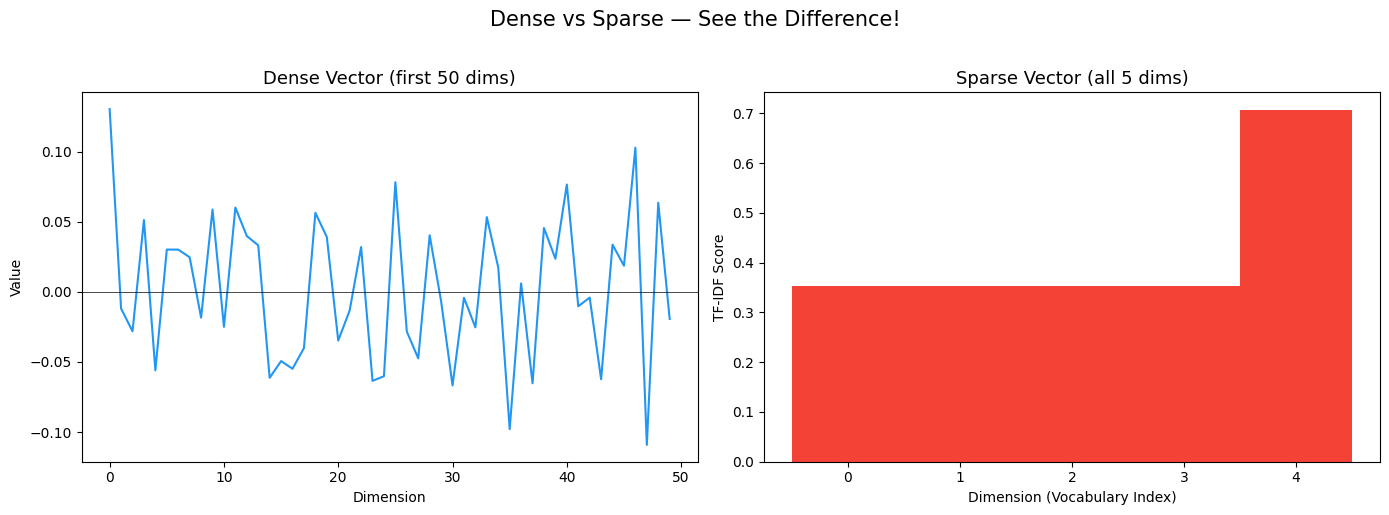

In [13]:
import matplotlib.pyplot as plt

# 1. Initialize models
vectorizer = TfidfVectorizer()

sentence = "the cat sat on the mat"

# 3. Encoding and Vectorizing
embeded_sentence = model.encode(sentence)
# Fit transform needs a list: [sentence]
vecorized_sentence = vectorizer.fit_transform([sentence])
vecorized_sentence_array = vecorized_sentence.toarray()[0]

# 4. Plotting
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Fixed the Hex color code to #2196F3
axes[0].plot(range(50), embeded_sentence[:50], color='#2196F3')
axes[0].set_title("Dense Vector (first 50 dims)", fontsize=13)
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Value")
axes[0].axhline(y=0, color="black", linewidth=0.5)

# Right chart
axes[1].bar(range(len(vecorized_sentence_array)), vecorized_sentence_array, color="#F44336", width=1.0)
axes[1].set_title(f"Sparse Vector (all {len(vecorized_sentence_array)} dims)", fontsize=13)
axes[1].set_xlabel("Dimension (Vocabulary Index)")
axes[1].set_ylabel("TF-IDF Score")

# SUPTITLE: The "Super Title" for the whole window
plt.suptitle("Dense vs Sparse — See the Difference!", fontsize=15, y=1.02)

plt.tight_layout()
plt.show()